In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/brats20-dataset-training-validation/BraTS2020_ValidationData/MICCAI_BraTS2020_ValidationData/name_mapping_validation_data.csv
/kaggle/input/brats20-dataset-training-validation/BraTS2020_ValidationData/MICCAI_BraTS2020_ValidationData/survival_evaluation.csv
/kaggle/input/brats20-dataset-training-validation/BraTS2020_ValidationData/MICCAI_BraTS2020_ValidationData/BraTS20_Validation_084/BraTS20_Validation_084_flair.nii
/kaggle/input/brats20-dataset-training-validation/BraTS2020_ValidationData/MICCAI_BraTS2020_ValidationData/BraTS20_Validation_084/BraTS20_Validation_084_t2.nii
/kaggle/input/brats20-dataset-training-validation/BraTS2020_ValidationData/MICCAI_BraTS2020_ValidationData/BraTS20_Validation_084/BraTS20_Validation_084_t1ce.nii
/kaggle/input/brats20-dataset-training-validation/BraTS2020_ValidationData/MICCAI_BraTS2020_ValidationData/BraTS20_Validation_084/BraTS20_Validation_084_t1.nii
/kaggle/input/brats20-dataset-training-validation/BraTS2020_ValidationData/MICCAI_Br

# adding data set

In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras import backend as K
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator

2025-11-28 12:43:12.775218: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764333792.951764      33 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764333793.003772      33 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


# data preprations

In [3]:
import os
import numpy as np
import nibabel as nib
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tqdm import tqdm

# 1. Define paths
data_path = "/kaggle/input/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData"

# Get patient IDs
patient_ids = [f for f in os.listdir(data_path) if not f.startswith('.')]
print(f"Total patients: {len(patient_ids)}")

# Preview a sample
sample_id = patient_ids[0]
sample_path = os.path.join(data_path, sample_id)
sample_files = os.listdir(sample_path)
print(f"Files for sample {sample_id}: {sample_files}")

Total patients: 371
Files for sample BraTS20_Training_083: ['BraTS20_Training_083_flair.nii', 'BraTS20_Training_083_t1.nii', 'BraTS20_Training_083_seg.nii', 'BraTS20_Training_083_t2.nii', 'BraTS20_Training_083_t1ce.nii']


# data loading and preprocessing

In [4]:


# 2. Data loading function with tumor slices prioritized
def load_data(patient_ids, data_path, num_slices=10):
    images, masks = [], []
    
    for patient_id in tqdm(patient_ids[:60]):  # Limit for faster testing
        patient_path = os.path.join(data_path, patient_id)
        files = os.listdir(patient_path)
        
        # Load modalities
        flair = nib.load(os.path.join(patient_path, [f for f in files if 'flair' in f.lower()][0])).get_fdata()
        t1 = nib.load(os.path.join(patient_path, [f for f in files if 't1.' in f.lower() and 't1ce' not in f.lower()][0])).get_fdata()
        t1ce = nib.load(os.path.join(patient_path, [f for f in files if 't1ce' in f.lower()][0])).get_fdata()
        t2 = nib.load(os.path.join(patient_path, [f for f in files if 't2' in f.lower()][0])).get_fdata()
        mask = nib.load(os.path.join(patient_path, [f for f in files if 'seg' in f.lower()][0])).get_fdata()
        
        # Stack modalities
        combined = np.stack([flair, t1, t1ce, t2], axis=-1)
        
        # Dataset-level normalization (here we normalize per patient, better: compute global mean/std)
        for i in range(4):
            combined[..., i] = (combined[..., i] - combined[..., i].mean()) / (combined[..., i].std() + 1e-8)
        
        # Binarize mask
        mask = (mask > 0).astype(np.float32)
        
        # Prioritize tumor slices
        tumor_slices = [i for i in range(mask.shape[2]) if np.any(mask[:, :, i] > 0)]
        if len(tumor_slices) >= num_slices:
            slice_range = tumor_slices[:num_slices]
        else:
            mid = mask.shape[2] // 2
            slice_range = list(tumor_slices) + list(range(mid - num_slices//2, mid + num_slices//2 + 1))[:num_slices - len(tumor_slices)]
        
        # Append slices
        for sl in slice_range:
            if 0 <= sl < combined.shape[2]:
                images.append(combined[:, :, sl, :])
                masks.append(mask[:, :, sl])
    
    return np.array(images), np.expand_dims(np.array(masks), -1)

# 3. Load data
X, y = load_data(patient_ids, data_path, num_slices=10)
print(f"Loaded data shape: {X.shape}, masks shape: {y.shape}")

# 4. Stratified train/val split based on tumor presence
has_tumor = np.array([int(np.any(mask > 0)) for mask in y])
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=has_tumor, random_state=42
)

print(f"Train shapes - X: {X_train.shape}, y: {y_train.shape}")
print(f"Val shapes - X: {X_val.shape}, y: {y_val.shape}")
print(f"Train tumor pixels: {100*np.mean(y_train):.2f}%")
print(f"Val tumor pixels: {100*np.mean(y_val):.2f}%")


   



100%|██████████| 60/60 [01:45<00:00,  1.76s/it]


Loaded data shape: (600, 240, 240, 4), masks shape: (600, 240, 240, 1)
Train shapes - X: (480, 240, 240, 4), y: (480, 240, 240, 1)
Val shapes - X: (120, 240, 240, 4), y: (120, 240, 240, 1)
Train tumor pixels: 0.68%
Val tumor pixels: 0.67%


# data augumentation

In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

def create_augmentation_generator(images, masks, batch_size=8, augment=True):
    if augment:
        image_datagen = ImageDataGenerator(
            rotation_range=20,
            width_shift_range=0.02,
            height_shift_range=0.05,
            zoom_range=0.1,
            horizontal_flip=True,
            vertical_flip=True,
            fill_mode='constant'
        )
        mask_datagen = ImageDataGenerator(
            rotation_range=20,
            width_shift_range=0.02,
            height_shift_range=0.05,
            zoom_range=0.1,
            horizontal_flip=True,
            vertical_flip=True,
            fill_mode='nearest'
        )
    else:
        image_datagen = ImageDataGenerator()
        mask_datagen  = ImageDataGenerator()

    seed = 42
    image_generator = image_datagen.flow(images, batch_size=batch_size, seed=seed)
    mask_generator  = mask_datagen.flow(masks,  batch_size=batch_size, seed=seed)

    while True:
        img_batch = next(image_generator)
        mask_batch = next(mask_generator)
        
        # Binarize masks after augmentation
        mask_batch = (mask_batch > 0.5).astype(np.float32)
        
        yield (img_batch, mask_batch)


# 2. Create generators
batch_size = 8
train_generator = create_augmentation_generator(X_train, y_train, batch_size=batch_size, augment=True)
val_generator   = create_augmentation_generator(X_val, y_val, batch_size=batch_size, augment=False)

# 3. Verify generator output
batch_images, batch_masks = next(train_generator)
print(f"First batch - Images shape: {batch_images.shape}, Masks shape: {batch_masks.shape}")
print(f"Image range: {batch_images.min()} to {batch_images.max()}")
print(f"Mask unique values: {np.unique(batch_masks)}")



First batch - Images shape: (8, 240, 240, 4), Masks shape: (8, 240, 240, 1)
Image range: -0.4796270728111267 to 7.962666034698486
Mask unique values: [0. 1.]


# u-net implimentation

In [6]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from tensorflow.keras import backend as K

# --- 1. Custom Loss and Metric Definitions ---

# Metric: Dice Coefficient (F1 Score)
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

# Loss: Tversky Loss (Optimized for Imbalanced Segmentation)
def tversky_loss(y_true, y_pred, alpha=0.3, beta=0.7, smooth=1e-6):
    """
    Tversky loss function with beta > 0.5 penalizes False Negatives (FN) 
    more than False Positives (FP) to force the model to capture the small target area.
    
    alpha = 1 - beta
    """
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    
    # True Positives, False Positives, False Negatives
    tp = K.sum(y_true_f * y_pred_f)
    fp = K.sum((1 - y_true_f) * y_pred_f)
    fn = K.sum(y_true_f * (1 - y_pred_f))
    
    # Tversky Index
    tversky_index = (tp + smooth) / (tp + alpha * fp + beta * fn + smooth)
    
    # Tversky Loss (to be minimized)
    return 1 - tversky_index

# --- 2. U-Net Architecture Helper (with Batch Normalization) ---

def conv_block(input_tensor, num_filters):
    # First Conv2D -> BatchNormalization -> ReLU
    x = Conv2D(num_filters, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(input_tensor)
    x = BatchNormalization()(x) 
    
    # Second Conv2D -> BatchNormalization -> ReLU
    x = Conv2D(num_filters, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(x)
    x = BatchNormalization()(x) 
    return x

# --- 3. U-Net Model Definition ---

def build_unet_improved_v2(input_shape=(240, 240, 4)):
    inputs = Input(input_shape)
    
    # === Encoder (Downsampling) ===
    c1 = conv_block(inputs, 64)
    p1 = MaxPooling2D((2, 2))(c1)
    
    c2 = conv_block(p1, 128)
    p2 = MaxPooling2D((2, 2))(c2)
    
    c3 = conv_block(p2, 256)
    p3 = MaxPooling2D((2, 2))(c3)
    
    c4 = conv_block(p3, 512)
    p4 = MaxPooling2D((2, 2))(c4)
    p4 = Dropout(0.3)(p4)

    # === Bottleneck ===
    c5 = conv_block(p4, 1024)
    c5 = Dropout(0.5)(c5)
    
    # === Decoder (Upsampling) ===
    u6 = UpSampling2D((2, 2))(c5)
    u6 = concatenate([u6, c4]) 
    c6 = conv_block(u6, 512)
    
    u7 = UpSampling2D((2, 2))(c6)
    u7 = concatenate([u7, c3]) 
    c7 = conv_block(u7, 256)
    
    u8 = UpSampling2D((2, 2))(c7)
    u8 = concatenate([u8, c2]) 
    c8 = conv_block(u8, 128)
    
    u9 = UpSampling2D((2, 2))(c8)
    u9 = concatenate([u9, c1]) 
    c9 = conv_block(u9, 64)
    
    # Output layer (240x240x1)
    # The initial bias is set to encourage positive predictions 
    # (Here, we set it to encourage an initial prediction of 0.5% positive pixels)
    positive_pixel_ratio = 0.005 # Estimate based on typical medical segmentation
    initial_bias = np.log(positive_pixel_ratio / (1 - positive_pixel_ratio)) 
    
    outputs = Conv2D(1, (1, 1), 
                     activation='sigmoid',
                     bias_initializer=tf.keras.initializers.Constant(initial_bias))(c9) 
    
    model = Model(inputs=[inputs], outputs=[outputs])
    
    # Compile using Tversky Loss and a standard LR
    model.compile(optimizer=Adam(learning_rate=1e-4), 
                  loss=tversky_loss, 
                  metrics=[dice_coef, 'accuracy'])
    return model

# --- 4. Model Instantiation and Callbacks ---

# Instantiate the final improved model
model = build_unet_improved_v2() 

# Define callbacks (Including Early Stopping and LR Scheduler)


# Display Model Summary
model.summary()

# --- 5. Training Command (Placeholder) ---



I0000 00:00:1764333912.574276      33 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 240, 240, 4)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 240, 240, 64)   │          2,368 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization       │ (None, 240, 240, 64)   │            256 │ conv2d[0][0]           │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 240, 240, 64)   │         36,928 │ batch_normalization[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_1     │ (None, 240, 240, 64)   │            256 │ conv2d_1[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d             │ (None, 120, 120, 64)   │              0 │ batch_normalization_1… │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 120, 120, 128)  │         73,856 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_2     │ (None, 120, 120, 128)  │            512 │ conv2d_2[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_3 (Conv2D)         │ (None, 120, 120, 128)  │        147,584 │ batch_normalization_2… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_3     │ (None, 120, 120, 128)  │            512 │ conv2d_3[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_1           │ (None, 60, 60, 128)    │              0 │ batch_normalization_3… │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_4 (Conv2D)         │ (None, 60, 60, 256)    │        295,168 │ max_pooling2d_1[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_4     │ (None, 60, 60, 256)    │          1,024 │ conv2d_4[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_5 (Conv2D)         │ (None, 60, 60, 256)    │        590,080 │ batch_normalization_4… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_5     │ (None, 60, 60, 256)    │          1,024 │ conv2d_5[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_2      

 Total params: 31,403,073 (119.79 MB)

 Trainable params: 31,391,297 (119.75 MB)

 Non-trainable params: 11,776 (46.00 KB)

# tranning data

In [7]:
# 3. Define callbacks
# Define callbacks for training (Ensure TensorFlow is imported as tf)
callbacks = [
    EarlyStopping(
        patience=15, # Increased patience 
        monitor='val_dice_coef',
        mode='max',
        restore_best_weights=True),
    ModelCheckpoint(
        'best_model_tversky.keras',
        monitor='val_dice_coef',
        save_best_only=True,
        mode='max'),
    # Learning Rate Scheduler: Reduces LR when val_dice_coef plateaus
    ReduceLROnPlateau(
        monitor='val_dice_coef',
        factor=0.5, # Reduce LR by 50%
        patience=5,
        mode='max',
        verbose=1,
        min_lr=1e-7)
]

# 4. Train the model

# To run the training, you would use this block (make sure your data generators are defined)
history = model.fit(
     train_generator,
     steps_per_epoch=len(X_train) // batch_size,
     epochs=100, 
     validation_data=val_generator,
     validation_steps=len(X_val) // batch_size,
     callbacks=callbacks
 )

Epoch 1/100


I0000 00:00:1764333930.380314      95 service.cc:148] XLA service 0x78052c002480 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1764333930.381075      95 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1764333931.907824      95 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1764333959.218391      95 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


60/60 ━━━━━━━━━━━━━━━━━━━━ 70s 415ms/step - accuracy: 0.9908 - dice_coef: 0.2620 - loss: 0.6806 - val_accuracy: 0.9580 - val_dice_coef: 0.1120 - val_loss: 0.8408 - learning_rate: 1.0000e-04
Epoch 2/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 16s 262ms/step - accuracy: 0.9948 - dice_coef: 0.5075 - loss: 0.4194 - val_accuracy: 0.9135 - val_dice_coef: 0.1142 - val_loss: 0.8256 - learning_rate: 1.0000e-04
Epoch 3/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 14s 234ms/step - accuracy: 0.9954 - dice_coef: 0.5390 - loss: 0.3888 - val_accuracy: 0.8877 - val_dice_coef: 0.0962 - val_loss: 0.8506 - learning_rate: 1.0000e-04
Epoch 4/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 16s 261ms/step - accuracy: 0.9956 - dice_coef: 0.5505 - loss: 0.3728 - val_accuracy: 0.9862 - val_dice_coef: 0.3712 - val_loss: 0.5239 - learning_rate: 1.0000e-04
Epoch 5/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 16s 263ms/step - accuracy: 0.9957 - dice_coef: 0.5934 - loss: 0.3357 - val_accuracy: 0.9904 - val_dice_coef: 0.4637 - val_loss: 0.4327 - learning_rate: 1.0000e-04
Ep

In [8]:
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.callbacks import ReduceLROnPlateau # Needed if the model was compiled or trained with it

# --- 1. Custom Loss and Metric Definitions (Tversky Model) ---

def dice_coef(y_true, y_pred, smooth=1e-7):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

# The Tversky Loss function used in the successful training run
def tversky_loss(y_true, y_pred, alpha=0.3, beta=0.7, smooth=1e-6):
    """Tversky loss function (assumed to be used for best_model_tversky.keras)."""
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    
    tp = K.sum(y_true_f * y_pred_f)
    fp = K.sum((1 - y_true_f) * y_pred_f)
    fn = K.sum(y_true_f * (1 - y_pred_f))
    
    # Tversky Index
    tversky_index = (tp + smooth) / (tp + alpha * fp + beta * fn + smooth)
    
    return 1 - tversky_index

# --- 2. Load the best saved model with all custom objects ---

best_model = tf.keras.models.load_model(
    'best_model_tversky.keras',
    custom_objects={
        # These are the functions the model was compiled/trained with:
        'dice_coef': dice_coef,
        'tversky_loss': tversky_loss, # <-- The actual loss function used for saving
        
        
    }
)



In [9]:


# --- 3. Evaluate on validation set ---


val_results = best_model.evaluate(val_generator, steps=len(X_val)//batch_size)
print("\nFinal Evaluation on Validation Set:")
print(f"Validation Loss: {val_results[0]:.4f}")
print(f"Validation Dice Coefficient: {val_results[1]:.4f}")
print(f"Validation Accuracy: {val_results[2]:.4f}")


15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - accuracy: 0.9985 - dice_coef: 0.8648 - loss: 0.1269

Final Evaluation on Validation Set:
Validation Loss: 0.1280
Validation Dice Coefficient: 0.8605
Validation Accuracy: 0.9985


In [10]:

# # --- 4. Evaluate on training set (for comparison) ---
train_results = best_model.evaluate(train_generator, steps=len(X_train)//batch_size)
print("\nEvaluation on Training Set:")
print(f"Training Loss: {train_results[0]:.4f}")
print(f"Training Dice Coefficient: {train_results[1]:.4f}")
print(f"Training Accuracy: {train_results[2]:.4f}")

60/60 ━━━━━━━━━━━━━━━━━━━━ 8s 136ms/step - accuracy: 0.9984 - dice_coef: 0.8763 - loss: 0.0954

Evaluation on Training Set:
Training Loss: 0.0993
Training Dice Coefficient: 0.8723
Training Accuracy: 0.9985


# Evaluation and Visualization

E0000 00:00:1764335439.626857      94 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1764335439.873798      94 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step

Detailed Metrics on Sample Validation Data:
Mean Accuracy: 0.9988
Mean Precision: 0.5706
Mean Recall: 0.6291
Mean Dice: 0.5936


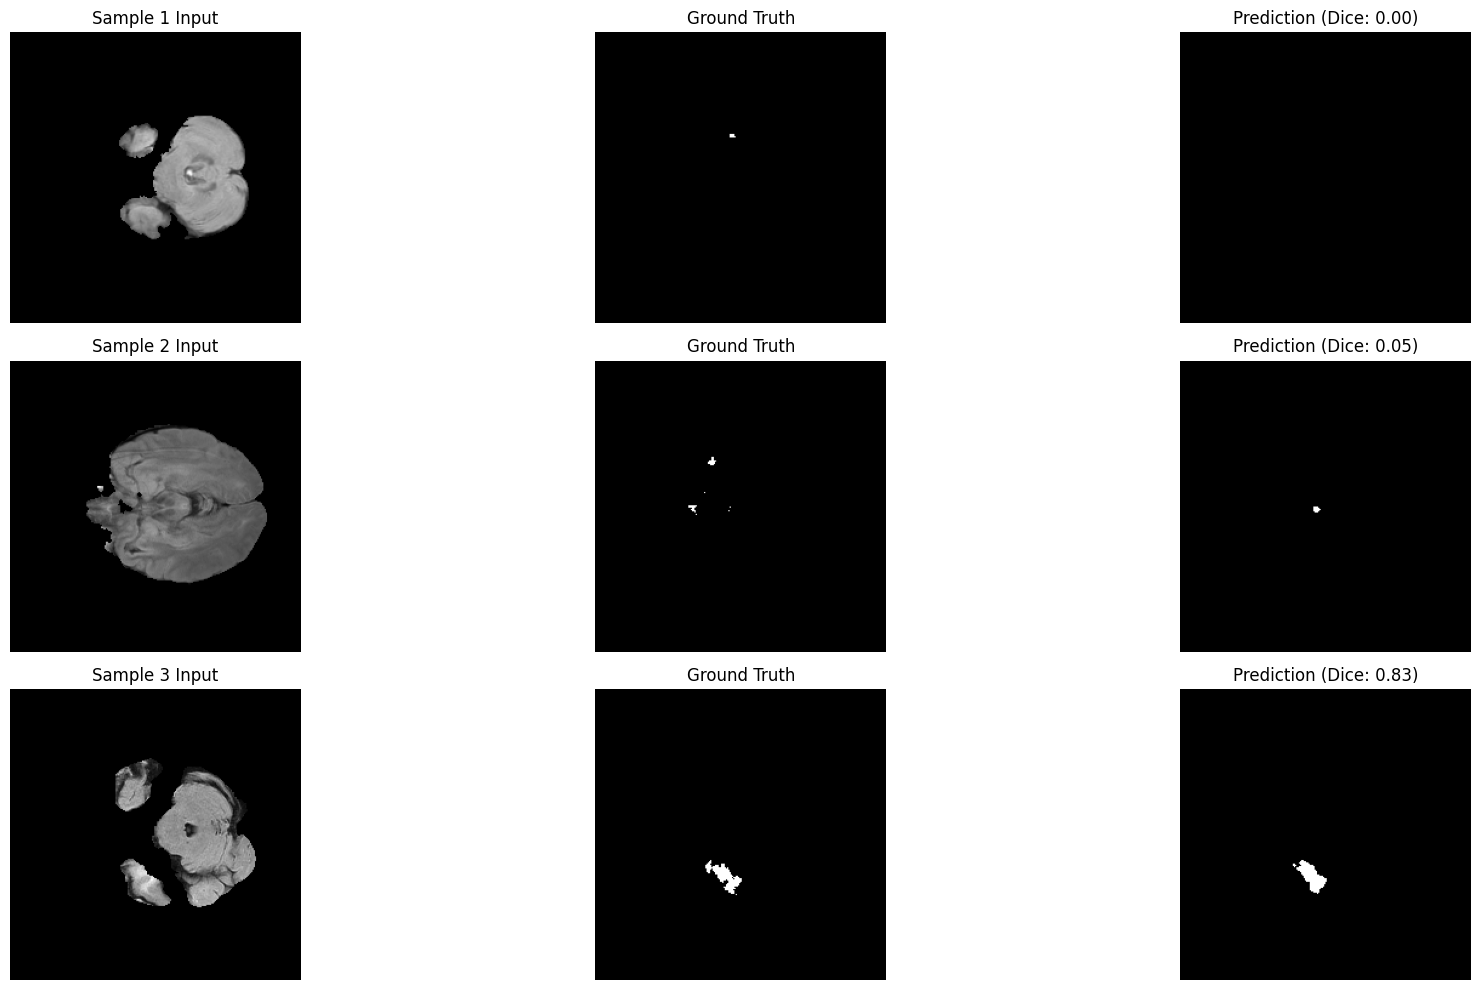

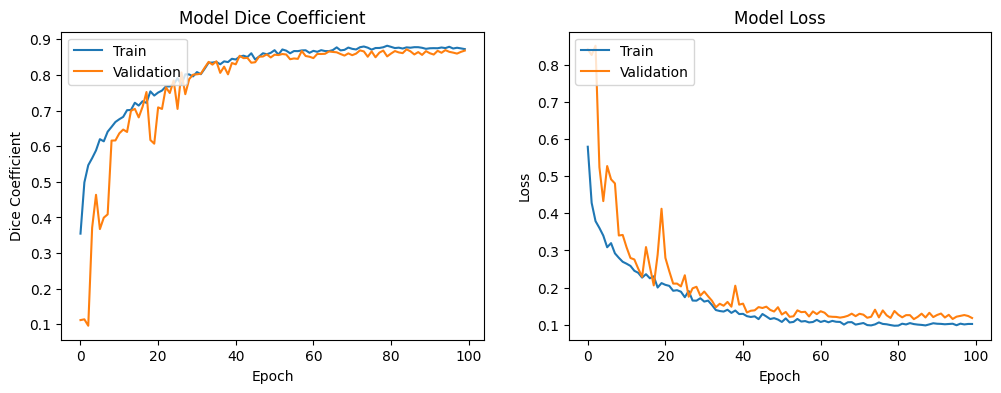

In [11]:




# 4. Detailed metrics calculation for sample validation data
def calculate_metrics(y_true, y_pred):
    y_pred = (y_pred > 0.5).astype(np.float32)
    y_true_f = y_true.flatten()
    y_pred_f = y_pred.flatten()

    tp = np.sum(y_true_f * y_pred_f)
    fp = np.sum((1 - y_true_f) * y_pred_f)
    fn = np.sum(y_true_f * (1 - y_pred_f))
    tn = np.sum((1 - y_true_f) * (1 - y_pred_f))

    accuracy = (tp + tn) / (tp + tn + fp + fn + 1e-7)
    precision = tp / (tp + fp + 1e-7)
    recall = tp / (tp + fn + 1e-7)
    dice = (2 * tp) / (2 * tp + fp + fn + 1e-7)

    return accuracy, precision, recall, dice

# 5. Evaluate on a small sample (optional)
sample_size = min(10, len(X_val))
sample_X = X_val[:sample_size]
sample_y = y_val[:sample_size]

preds = best_model.predict(sample_X)

accuracies, precisions, recalls, dices = [], [], [], []

for i in range(sample_size):
    acc, prec, rec, dice = calculate_metrics(sample_y[i], preds[i])
    accuracies.append(acc)
    precisions.append(prec)
    recalls.append(rec)
    dices.append(dice)

print("\nDetailed Metrics on Sample Validation Data:")
print(f"Mean Accuracy: {np.mean(accuracies):.4f}")
print(f"Mean Precision: {np.mean(precisions):.4f}")
print(f"Mean Recall: {np.mean(recalls):.4f}")
print(f"Mean Dice: {np.mean(dices):.4f}")

# 6. Visualize predictions vs ground truth
plt.figure(figsize=(20, 10))
for i in range(min(3, sample_size)):
    plt.subplot(3, 3, i*3 + 1)
    plt.imshow(sample_X[i, ..., 0], cmap='gray')
    plt.title(f"Sample {i+1} Input")
    plt.axis('off')

    plt.subplot(3, 3, i*3 + 2)
    plt.imshow(sample_y[i, ..., 0], cmap='gray')
    plt.title("Ground Truth")
    plt.axis('off')

    plt.subplot(3, 3, i*3 + 3)
    plt.imshow(preds[i, ..., 0] > 0.5, cmap='gray')
    plt.title(f"Prediction (Dice: {dices[i]:.2f})")
    plt.axis('off')

plt.tight_layout()
plt.show()

# 7. Plot training history
def plot_history(history):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['dice_coef'])
    plt.plot(history.history['val_dice_coef'])
    plt.title('Model Dice Coefficient')
    plt.ylabel('Dice Coefficient')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')

    plt.show()

plot_history(history)


saving data

In [12]:
# Save the final model
model.save('brain_tumor_segmentation_model.h5')

